# Ewaluacja modelu `corner_gru_sequence`

Notatnik odtwarza walidację modelu z [outputs/calibration_net/best_model.pth](outputs/calibration_net/best_model.pth):

- generuje losowe sekwencje narożników planszy w pamięci,
- zachowuje wartości `ground truth` parametrów kamery,
- przepuszcza sekwencje przez zapisany model,
- porównuje predykcje z wartościami referencyjnymi,
- oblicza odchyłki i tworzy wykresy.

Nie jest wykonywane ponowne trenowanie modelu. Dane walidacyjne są generowane deterministycznie z seedem zapisanym w checkpointcie.

## 1. Import bibliotek i konfiguracja środowiska

Kod korzysta z tych samych klas generatora danych i modelu co trening. Ścieżka projektu jest wyznaczana względem lokalizacji notatnika.

In [4]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader

# Znajdź katalog projektu, niezależnie od bieżącego katalogu notebooka.
PROJECT_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "src" / "networks_tool").exists():
        PROJECT_ROOT = candidate
        break
if PROJECT_ROOT is None:
    raise FileNotFoundError("Nie znaleziono katalogu projektu z src/networks_tool.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.networks_tool.dataset import SyntheticCornerSequenceCalibrationDataset
from src.networks_tool.models import CornerGRUSequenceCalibrationNet

CHECKPOINT_PATH = PROJECT_ROOT / "outputs" / "calibration_net" / "best_model.pth"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Projekt: {PROJECT_ROOT}")
print(f"Urządzenie: {DEVICE}")
print(f"Checkpoint: {CHECKPOINT_PATH}")

Projekt: /home/dominik-babiarczyk/studia/semestr10/camera-calibration
Urządzenie: cuda
Checkpoint: /home/dominik-babiarczyk/studia/semestr10/camera-calibration/outputs/calibration_net/best_model.pth


## 2. Wczytanie checkpointu i konfiguracji

Checkpoint zawiera architekturę konfiguracji, wagi modelu oraz seed i liczbę sekwencji użytych do walidacji.

In [5]:
checkpoint = torch.load(CHECKPOINT_PATH, map_location="cpu", weights_only=False)
cfg = checkpoint["config"]

model = CornerGRUSequenceCalibrationNet(num_outputs=cfg.num_outputs).to(DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print(f"Model: {cfg.model_name}")
print(f"Najlepsza epoka: {checkpoint['epoch']}")
print(f"Val loss zapisany w checkpointcie: {checkpoint['val_loss']:.10f}")
print(f"Sekwencja: {cfg.sequence_length} klatek")
print(f"Walidacja: {cfg.max_validation_items:,} sekwencji")
print(f"Seed walidacyjny: {cfg.synthetic_seed + 1_000_000}")

Model: corner_gru_sequence
Najlepsza epoka: 4
Val loss zapisany w checkpointcie: 0.0017166547
Sekwencja: 10 klatek
Walidacja: 10,000 sekwencji
Seed walidacyjny: 1000042


## 3. Losowe dane walidacyjne i wartości `ground truth`

Generator tworzy sekwencje w pamięci. Dla każdej sekwencji losuje jeden zestaw parametrów kamery, a następnie generuje 10 różnych położeń planszy. Używamy deterministycznego generatora, aby uzyskać ten sam zbiór walidacyjny co podczas treningu.

In [6]:
val_dataset = SyntheticCornerSequenceCalibrationDataset(
    num_sequences=cfg.max_validation_items,
    config=cfg,
    seed=cfg.synthetic_seed + 1_000_000,
    deterministic=True,
    split_name="notebook-validation",
)

val_loader = DataLoader(
    val_dataset,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=True,
)

print(f"Liczba sekwencji: {len(val_dataset):,}")
example_x, example_gt = val_dataset[0]
print(f"Kształt wejścia jednej sekwencji: {tuple(example_x.shape)}")
print(f"Kształt ground truth: {tuple(example_gt.shape)}")
print("Przykładowy ground truth:", example_gt.numpy())

Liczba sekwencji: 10,000
Kształt wejścia jednej sekwencji: (10, 40, 4)
Kształt ground truth: (9,)
Przykładowy ground truth: [ 0.8559398   1.8515402   0.45855638  0.47172576 -0.21229698 -0.29108793
  0.02034445  0.1767355  -0.07591203]


## 4. Predykcja modelu

Model nie dostaje obrazów, tylko cechy narożników o kształcie `(batch, czas, narożniki, cechy)`. Ground truth jest zachowany przed predykcją i posłuży do obliczenia błędów.

In [7]:
predictions = []
ground_truth = []

with torch.no_grad():
    for features, targets in val_loader:
        outputs = model(features.to(DEVICE)).cpu()
        predictions.append(outputs.numpy())
        ground_truth.append(targets.numpy())

predictions = np.concatenate(predictions, axis=0)
ground_truth = np.concatenate(ground_truth, axis=0)
errors = predictions - ground_truth
absolute_errors = np.abs(errors)

print(f"Predykcje: {predictions.shape}")
print(f"Ground truth: {ground_truth.shape}")

Predykcje: (10000, 9)
Ground truth: (10000, 9)


## 5. Porównanie predykcji z `ground truth`

Dodatni błąd oznacza zawyżenie predykcji, a ujemny — jej zaniżenie.

In [13]:
import cv2
from IPython.display import display, Markdown

parameter_names = ["fx_norm", "fy_norm", "cx_norm", "cy_norm", "k1", "k2", "p1", "p2", "k3"]
NUM_OPENCV_EXAMPLES = 5

# Punkty 3D planszy używane przez generator danych.
board_points = np.zeros((cfg.synthetic_board_rows * cfg.synthetic_board_cols, 3), dtype=np.float32)
board_points[:, :2] = np.mgrid[
    0:cfg.synthetic_board_cols,
    0:cfg.synthetic_board_rows,
].T.reshape(-1, 2)
board_points[:, :2] *= cfg.synthetic_square_size

# Klasyczna kalibracja OpenCV jest wykonywana tylko dla pięciu pierwszych sekwencji.
opencv_predictions = []
for sequence_index in range(NUM_OPENCV_EXAMPLES):
    features, _ = val_dataset[sequence_index]
    normalized_points = features.numpy()[:, :, :2]
    image_points = [
        (points * np.array([cfg.synthetic_image_width, cfg.synthetic_image_height])).astype(np.float32)
        for points in normalized_points
    ]
    object_points = [board_points.copy() for _ in image_points]

    try:
        _, camera_matrix, distortion_coefficients, _, _ = cv2.calibrateCamera(
            object_points,
            image_points,
            (cfg.synthetic_image_width, cfg.synthetic_image_height),
            None,
            None,
        )
        opencv_predictions.append([
            camera_matrix[0, 0] / cfg.synthetic_image_width,
            camera_matrix[1, 1] / cfg.synthetic_image_height,
            camera_matrix[0, 2] / cfg.synthetic_image_width,
            camera_matrix[1, 2] / cfg.synthetic_image_height,
            *distortion_coefficients.ravel()[:5],
        ])
    except cv2.error:
        opencv_predictions.append([np.nan] * len(parameter_names))

opencv_predictions = np.asarray(opencv_predictions, dtype=np.float32)
opencv_ground_truth = ground_truth[:NUM_OPENCV_EXAMPLES]
opencv_model_predictions = predictions[:NUM_OPENCV_EXAMPLES]
opencv_model_errors = opencv_model_predictions - opencv_ground_truth
opencv_errors = opencv_predictions - opencv_ground_truth
opencv_absolute_errors = np.abs(opencv_errors)

# Jedna tabela podsumowująca pięć przykładów OpenCV.
opencv_table = pd.DataFrame(opencv_predictions, columns=parameter_names)
opencv_table.insert(0, "example", np.arange(1, len(opencv_table) + 1))
display(Markdown("### Predykcje OpenCV dla pięciu przykładów"))
display(opencv_table)

# Osobne tabele dla każdego parametru: model GRU i klasyczne OpenCV.
comparisons = {}
for index, name in enumerate(parameter_names):
    comparisons[name] = pd.DataFrame({
        "ground_truth": opencv_ground_truth[:, index],
        "prediction_gru": opencv_model_predictions[:, index],
        "error_gru": opencv_model_errors[:, index],
        "opencv_prediction": opencv_predictions[:, index],
        "opencv_error": opencv_errors[:, index],
        "opencv_absolute_error": opencv_absolute_errors[:, index],
    })

for name, table in comparisons.items():
    display(Markdown(f"### {name} — pięć przykładów"))
    display(table)

### Predykcje OpenCV dla pięciu przykładów

,example,fx_norm,fy_norm,cx_norm,cy_norm,k1,k2,p1,p2,k3
0,1,0.855939,1.851539,0.458556,0.471726,-0.212297,-0.291076,0.020344,0.176735,-0.076142
1,2,0.875033,1.310639,0.522702,0.525783,0.225212,0.040475,-0.040037,-0.089862,-0.039715
2,3,1.229414,1.572728,0.506361,0.522826,0.665201,0.231037,-0.064709,-0.155765,0.031170
3,4,0.972928,1.609512,0.501774,0.501213,0.617537,0.187149,-0.040227,-0.150636,0.107879
4,5,1.116304,1.219708,0.470106,0.481220,0.146229,-0.163631,0.140339,-0.023307,0.124470


### fx_norm — pięć przykładów

,ground_truth,prediction_gru,error_gru,opencv_prediction,opencv_error,opencv_absolute_error
0,0.855940,0.886852,0.030912,0.855939,-7.748604e-07,7.748604e-07
1,0.875034,0.889798,0.014764,0.875033,-2.384186e-07,2.384186e-07
2,1.229414,1.238603,0.009189,1.229414,1.192093e-07,1.192093e-07
3,0.972927,0.960131,-0.012796,0.972928,5.364418e-07,5.364418e-07
4,1.116304,1.089106,-0.027198,1.116304,8.344650e-07,8.344650e-07


### fy_norm — pięć przykładów

...

,ground_truth,prediction_gru,error_gru,opencv_prediction,opencv_error,opencv_absolute_error
0,0.020344,0.028569,0.008225,0.020344,1.117587e-08,1.117587e-08
1,-0.040037,-0.036565,0.003472,-0.040037,-8.568168e-08,8.568168e-08
2,-0.064709,-0.055119,0.009590,-0.064709,-9.685755e-08,9.685755e-08
3,-0.040227,-0.019191,0.021036,-0.040227,-3.725290e-08,3.725290e-08
4,0.140339,0.142121,0.001781,0.140339,1.639128e-07,1.639128e-07


### p2 — pięć przykładów

,ground_truth,prediction_gru,error_gru,opencv_prediction,opencv_error,opencv_absolute_error
0,0.176736,0.168217,-0.008518,0.176735,-1.639128e-07,1.639128e-07
1,-0.089863,-0.081209,0.008654,-0.089862,3.576279e-07,3.576279e-07
2,-0.155765,-0.151480,0.004284,-0.155765,1.937151e-07,1.937151e-07
3,-0.150636,-0.154713,-0.004076,-0.150636,1.192093e-07,1.192093e-07
4,-0.023307,-0.019990,0.003317,-0.023307,5.029142e-08,5.029142e-08


### k3 — pięć przykładów

,ground_truth,prediction_gru,error_gru,opencv_prediction,opencv_error,opencv_absolute_error
0,-0.075912,-0.013190,0.062722,-0.076142,-0.000230,0.000230
1,-0.039864,-0.005274,0.034589,-0.039715,0.000149,0.000149
2,0.030331,0.003476,-0.026855,0.031170,0.000839,0.000839
3,0.107438,0.007481,-0.099957,0.107879,0.000442,0.000442
4,0.124999,-0.011422,-0.136421,0.124470,-0.000529,0.000529


## 6. Metryki jakości

Raport obejmuje MAE, RMSE, bias, odchylenie standardowe błędu oraz 95. percentyl błędu bezwzględnego. Dodatkowo błędy parametrów geometrycznych są przeliczane na piksele dla obrazu 640 × 480.

In [9]:
mae = np.mean(absolute_errors, axis=0)
rmse = np.sqrt(np.mean(errors**2, axis=0))
bias = np.mean(errors, axis=0)
error_std = np.std(errors, axis=0)
abs_error_p95 = np.quantile(absolute_errors, 0.95, axis=0)

# Taka sama funkcja straty jak w treningu.
log_cosh_loss = np.mean(np.log(np.cosh(errors)))

metrics = pd.DataFrame({
    "parameter": parameter_names,
    "MAE": mae,
    "RMSE": rmse,
    "bias": bias,
    "error_std": error_std,
    "abs_error_p95": abs_error_p95,
})

pixel_scales = np.array([640, 480, 640, 480, 1, 1, 1, 1, 1], dtype=float)
metrics["MAE_pixels_or_coeff"] = mae * pixel_scales
metrics["RMSE_pixels_or_coeff"] = rmse * pixel_scales
metrics["bias_pixels_or_coeff"] = bias * pixel_scales

print(f"LogCoshLoss: {log_cosh_loss:.10f}")
metrics.round(8)

LogCoshLoss: 0.0017166558


,parameter,MAE,RMSE,bias,error_std,abs_error_p95,MAE_pixels_or_coeff,RMSE_pixels_or_coeff,bias_pixels_or_coeff
0,fx_norm,0.020178,0.025272,-0.011335,0.022587,0.048909,12.913692,16.173874,-7.254431
1,fy_norm,0.021668,0.028768,0.002299,0.028676,0.056771,10.400647,13.808443,1.103476
2,cx_norm,0.012448,0.015555,0.001346,0.015497,0.030310,7.966705,9.955416,0.861153
3,cy_norm,0.013580,0.017085,-0.000884,0.017062,0.034255,6.518542,8.200766,-0.424451
4,k1,0.027470,0.035369,0.002359,0.035290,0.070719,0.027470,0.035369,0.002359
5,k2,0.092660,0.119397,0.015802,0.118347,0.239572,0.092660,0.119398,0.015802
6,p1,0.010063,0.012455,0.008443,0.009157,0.024003,0.010063,0.012455,0.008443
7,p2,0.008946,0.011452,-0.001817,0.011307,0.022656,0.008946,0.011452,-0.001817
8,k3,0.099863,0.115260,-0.004151,0.115185,0.190055,0.099863,0.115260,-0.004151


## 7. Wizualizacja wyników

Pierwszy wykres pokazuje `ground truth` i predykcję. Linia przerywana oznacza idealne dopasowanie $y=x$. Drugi wykres przedstawia rozkład błędów dla każdego parametru.

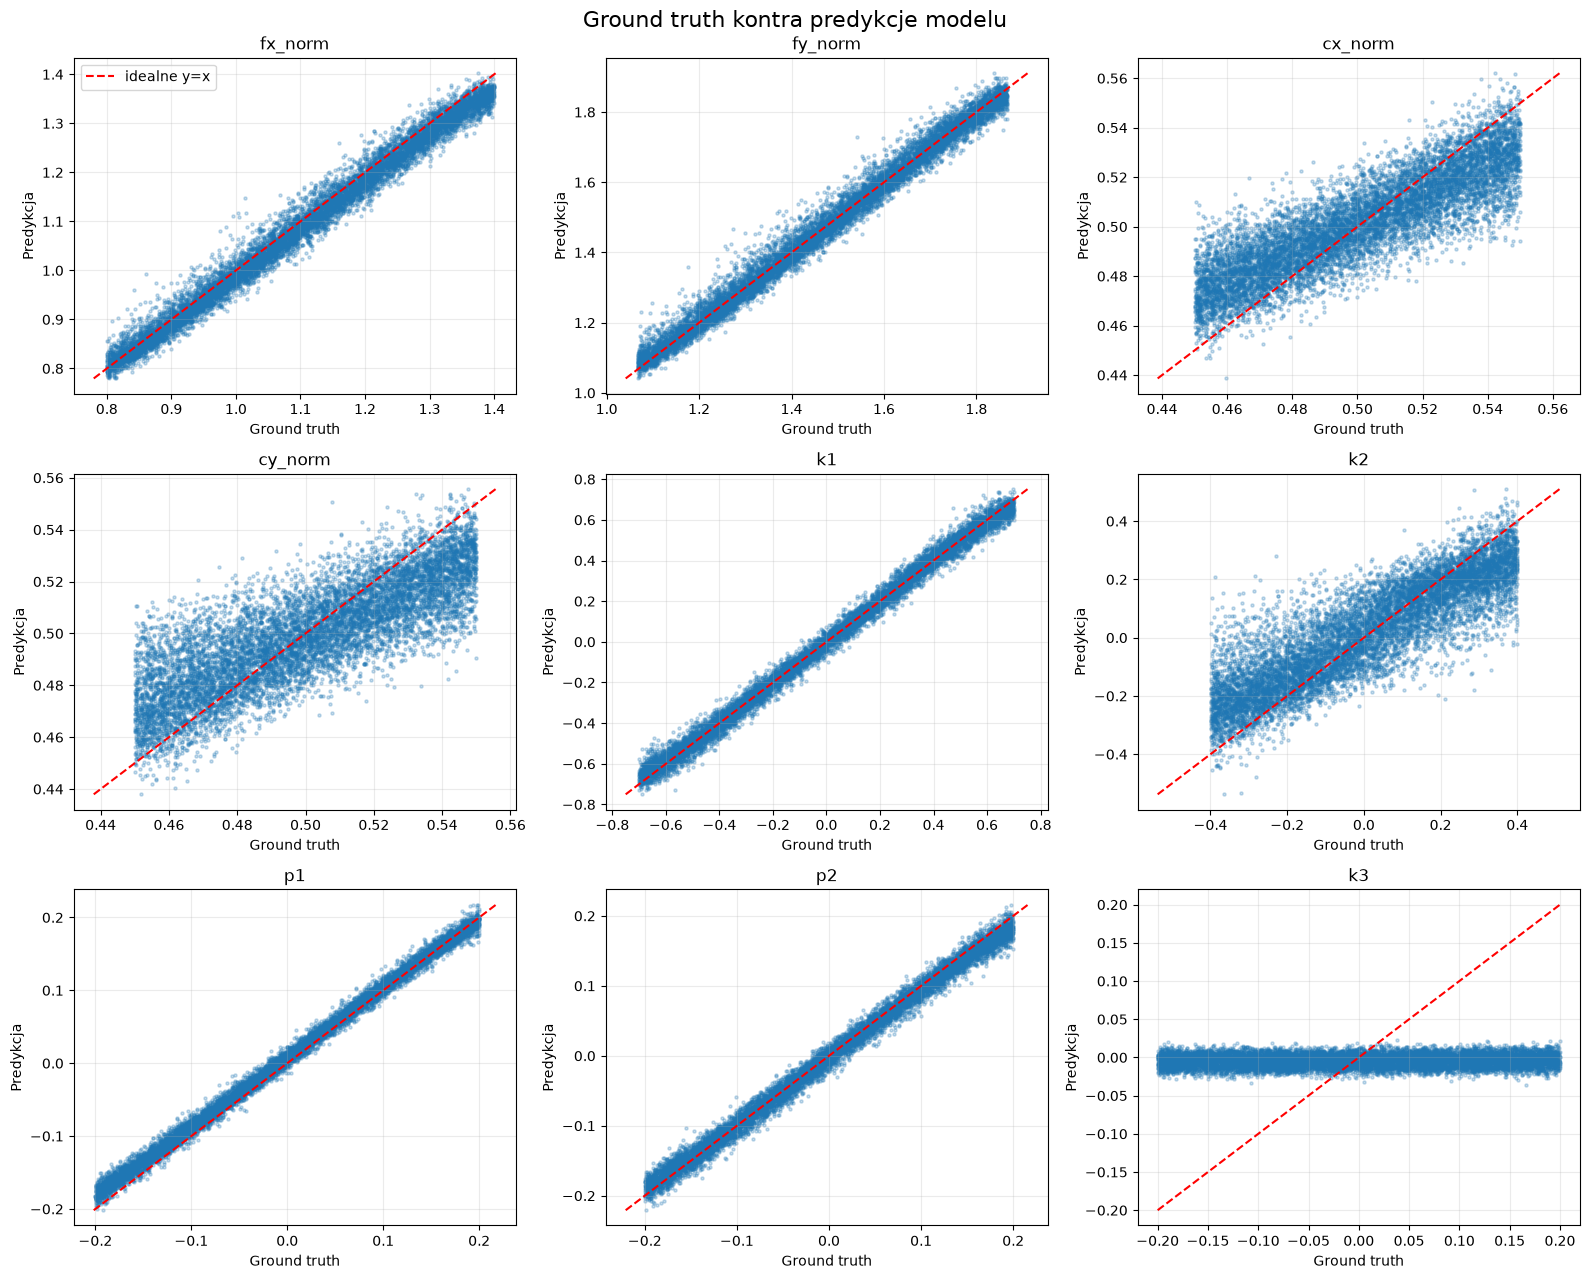

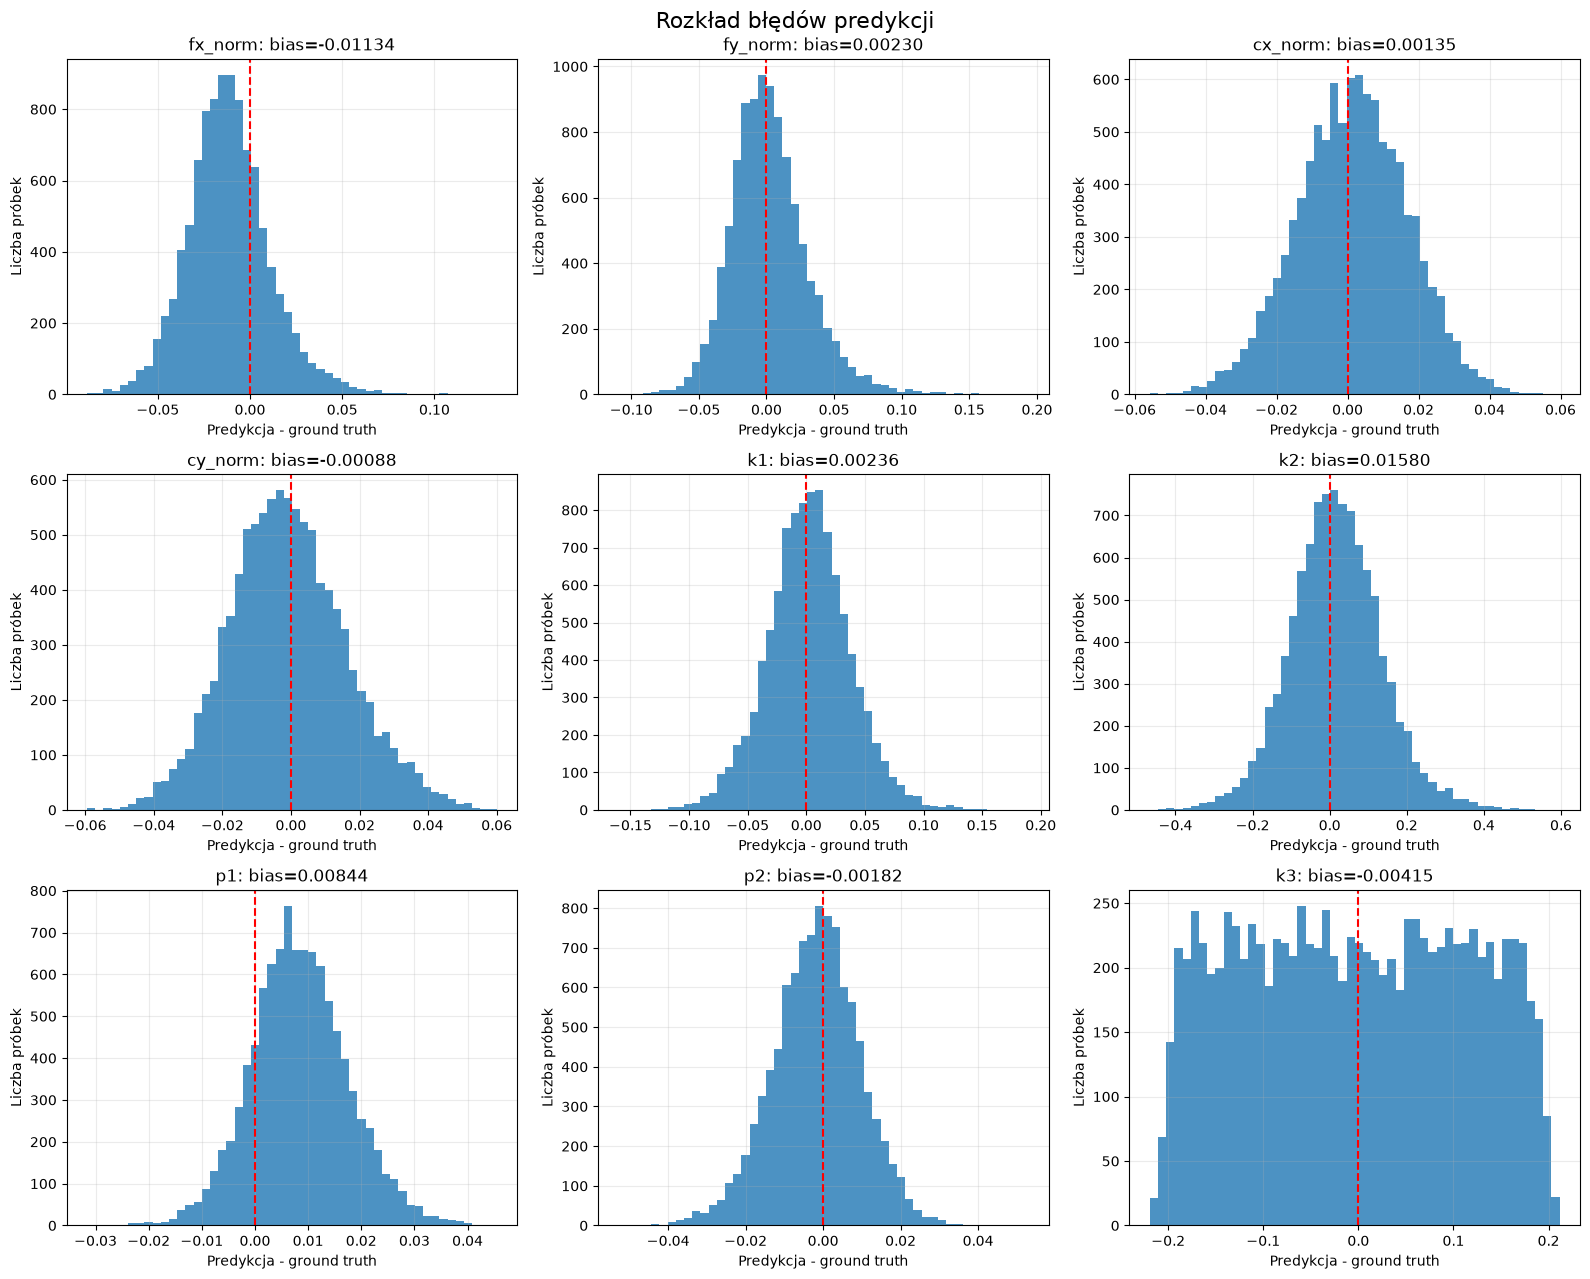

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(16, 13))
for index, (ax, name) in enumerate(zip(axes.ravel(), parameter_names)):
    ax.scatter(ground_truth[:, index], predictions[:, index], s=5, alpha=0.25)
    limits = [
        min(ground_truth[:, index].min(), predictions[:, index].min()),
        max(ground_truth[:, index].max(), predictions[:, index].max()),
    ]
    ax.plot(limits, limits, "r--", linewidth=1.5, label="idealne y=x")
    ax.set_title(name)
    ax.set_xlabel("Ground truth")
    ax.set_ylabel("Predykcja")
    ax.grid(alpha=0.25)
    if index == 0:
        ax.legend()

fig.suptitle("Ground truth kontra predykcje modelu", fontsize=16)
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 3, figsize=(16, 13))
for index, (ax, name) in enumerate(zip(axes.ravel(), parameter_names)):
    ax.hist(errors[:, index], bins=50, alpha=0.8)
    ax.axvline(0.0, color="red", linestyle="--", linewidth=1.5)
    ax.set_title(f"{name}: bias={bias[index]:.5f}")
    ax.set_xlabel("Predykcja - ground truth")
    ax.set_ylabel("Liczba próbek")
    ax.grid(alpha=0.25)

fig.suptitle("Rozkład błędów predykcji", fontsize=16)
fig.tight_layout()
plt.show()

## 8. Interpretacja

Największe wartości MAE i RMSE wskazują parametry, które model przewiduje najgorzej. Dla $f_x$, $f_y$, $c_x$ i $c_y$ dodatkowe kolumny w tabeli pokazują odchyłki w pikselach; dla współczynników dystorsji pozostają w ich naturalnej skali.